## Collect data

In [13]:
import os
import pandas as pd
import numpy as np
data_dir = '/cosma8/data/do012/dc-he4/analysis'

datadict = {}
for lc in range(1728):
    lc00 = f'{lc:04d}'

    filename = f'{data_dir}/lc{lc00}/h0_mcmc_joint_scatter_random.csv'

    # check if file exists
    if os.path.exists(filename):
        df = pd.read_csv(filename)

        # save to df
        if 'delta' not in list(datadict.keys()):  # datadict.keys() is of type dict_keys
            for key in df.keys():           # load all data
                datadict[key] = df[key]

            length = len(df[key])           # register lightcone number
            datadict['Lightcone'] = np.full(length, lc)
        else:
            for key in df.keys():           # load all data
                datadict[key] = np.concatenate((datadict[key], df[key]))

            length = len(df[key])           # register lightcone number
            datadict['Lightcone'] = np.concatenate((datadict['Lightcone'], np.full(length, lc)))

    else:
        print(lc00, 'h0_mcmc_joint_scatter_random.csv not found.')
        continue
    
data = pd.DataFrame(datadict)

data

1181 h0_mcmc_joint_scatter_random.csv not found.
1215 h0_mcmc_joint_scatter_random.csv not found.
1465 h0_mcmc_joint_scatter_random.csv not found.
1466 h0_mcmc_joint_scatter_random.csv not found.
1467 h0_mcmc_joint_scatter_random.csv not found.
1468 h0_mcmc_joint_scatter_random.csv not found.
1469 h0_mcmc_joint_scatter_random.csv not found.
1470 h0_mcmc_joint_scatter_random.csv not found.
1471 h0_mcmc_joint_scatter_random.csv not found.
1472 h0_mcmc_joint_scatter_random.csv not found.
1473 h0_mcmc_joint_scatter_random.csv not found.
1474 h0_mcmc_joint_scatter_random.csv not found.
1475 h0_mcmc_joint_scatter_random.csv not found.
1476 h0_mcmc_joint_scatter_random.csv not found.
1477 h0_mcmc_joint_scatter_random.csv not found.
1478 h0_mcmc_joint_scatter_random.csv not found.
1479 h0_mcmc_joint_scatter_random.csv not found.
1480 h0_mcmc_joint_scatter_random.csv not found.
1481 h0_mcmc_joint_scatter_random.csv not found.
1482 h0_mcmc_joint_scatter_random.csv not found.
1483 h0_mcmc_joint_s

,relation1,relation2,delta,delta_err_lower,delta_err_upper,vlon,vlon_err_lower,vlon_err_upper,vlat,vlat_err_lower,vlat_err_upper,convergence_time,Lightcone
0,LX-T,YSZ-T,0.019424,0.013735,0.021060,-11.995856,68.535352,53.633703,9.513562,41.790583,41.320951,173.077658,0
1,LX-T,YSZ-T,0.016749,0.011587,0.017876,47.990661,62.720639,71.684809,-14.722652,42.854910,43.362432,130.074512,1
2,LX-T,YSZ-T,0.016110,0.011303,0.018088,-35.999998,76.391590,68.357278,10.555681,47.682180,45.198922,172.691539,2
3,LX-T,YSZ-T,0.028742,0.018076,0.019833,-59.987853,53.310790,40.309524,-26.273758,33.785227,28.875199,182.714602,3
4,LX-T,YSZ-T,0.022769,0.014483,0.016542,131.994391,80.426607,66.667021,41.952776,35.516736,31.632516,182.426425,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,LX-T,YSZ-T,0.041798,0.022457,0.019970,95.936479,32.148428,24.513027,12.866707,20.003932,23.069274,215.573377,1460
1459,LX-T,YSZ-T,0.016290,0.011440,0.016202,47.952361,77.905740,107.602190,-26.322605,41.692182,51.948995,138.990323,1461
1460,LX-T,YSZ-T,0.032215,0.020443,0.020924,-35.776254,32.552246,34.587229,-5.946486,28.165769,25.669599,232.501451,1462
1461,LX-T,YSZ-T,0.018310,0.012580,0.016671,107.981963,93.865017,62.646089,-29.428781,37.987087,44.361724,208.419196,1463


In [14]:
# Get the significance
significance = data['delta'] / data['delta_err_lower']
data['Significance'] = significance
data['DeltaH0'] = data['delta'] * 2 * 100 # to percentage
data.to_csv('../data/analysis_all/h0_mc_joint_scatter_random.csv')

## Load functions

In [15]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import matplotlib.pyplot as plt
from scipy.special import erfinv
import math
import clusterfit as cf
import clusterplot as cp
plt.style.use('./nice.mplstyle')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
def load_data(file_path, data_type='mc'):
    data = pd.read_csv(file_path)
    if data_type == 'direct_compare':
        data['Delta_H0'] *= 100
    return data

def extract_data(data, relation):
    """Deal with my messy naming conventions."""
    if 'scaling_relation' in data.columns:
        df = data[data['scaling_relation'] == relation]
    elif 'Relations' in data.columns:
        df = data[data['Relations'] == relation]
    else:
        raise Exception('Relation/scaling relation column not found or recognised.')
    
    if 'DeltaH0' in df.columns:
        delta_h0 = df['DeltaH0'].values
    elif '$\Delta H_0\,(\%)$' in df.columns:
        delta_h0 = df['$\Delta H_0\,(\%)$'].values
    elif 'Delta_H0' in df.columns:
        delta_h0 = df['Delta_H0'].values 
    else:
        raise Exception('The delta H0 column not found or recognised.')
    
    
    if 'Significance $(\sigma)$' in df.columns:
        significance = df['Significance $(\sigma)$'].values
    elif 'Significance' in df.columns:
        significance = df['Significance'].values
    else:
        raise Exception('The significance column not found or recognised.')
    return delta_h0, significance

def calculate_sigma_p_value(delta_h0_proj, target_value):
    """Calculate the p-value by number of sigma deviation from the mean."""
    median = np.median(delta_h0_proj)
    sigma_84th = np.percentile(delta_h0_proj, 84)
    sigma = sigma_84th - median
    sigma_deviation = np.abs((target_value - median) / sigma)
    p_value_sigma = 1 - math.erf(sigma_deviation / np.sqrt(2))
    return sigma_deviation, p_value_sigma

def calculate_evt_p_value(delta_h0_proj, target_value, percentile=90):
    # Determine the threshold
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold  # Tail data

    # Fit GPD to the tail data
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # Tail survival probability (proportion of data in the tail)
    tail_prob = np.sum(delta_h0_proj >= threshold) / len(delta_h0_proj)

    if target_value > threshold:
        # Conditional probability adjusted to match at the threshold
        p_value_evt = (1 - genpareto.cdf(target_value - threshold, *params)) * tail_prob
    else:
        # Empirical CDF for the bulk region
        p_value_evt = np.sum(delta_h0_proj >= target_value) / len(delta_h0_proj)

    # Transform to sigma (Gaussian equivalent deviation)
    sigma_deviation = np.sqrt(2) * erfinv(1 - p_value_evt)

    return p_value_evt, sigma_deviation

# The first projection function
def default_proj(delta_H0, n_sigma):
    return delta_H0 - delta_H0 / n_sigma

In [17]:
!ls /cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all

bf_mc_all.csv			  h0_mc_all.csv
bf_mc_all_scatter.csv		  h0_mc_all_full.csv
bf_mc_random.csv		  h0_mc_joint_all.csv
bf_mc_scatter_random.csv	  h0_mc_joint_scatter_all.csv
bf_mc_zcos.csv			  h0_mc_joint_scatter_random.csv
bf_truth.csv			  h0_mcmc_random.csv
concatenated_fit_all.csv	  h0_mc_scatter.csv
concatenated_fit_all_mc.csv	  h0_mc_scatter_random.csv
concatenated_fit_all_scatter.csv  h0_mc_zcos.csv
h0_angle_constraint_mc.csv	  scatter_LX-T_added_scatter.csv
h0_angle_constraint_scan.csv	  scatter_LX-T.csv
h0_angle_constraints.csv	  scatter_M-T.csv
h0_direct_compare.csv		  scatter_YSZ-T_added_scatter.csv
h0_direct_compare_scatter.csv	  scatter_YSZ-T.csv


## Small plots for appendices
The MCMC run, for Lx-T and Ysz-T, output data and plot.

### Get data for separate relations (no scatter)

In [23]:
import os
import pandas as pd
import numpy as np
data_dir = '/cosma8/data/do012/dc-he4/analysis'

h0_vari = np.array([])
n_sigma = np.array([])
relations = []
for relation, relation_name in zip(['LX-T', 'YSZ-T', 'M-T'], 
                                   ['$L_\\mathrm{{X}}-T$',
                                    '$Y_\\mathrm{{SZ}}-T$',
                                    '$M_\\mathrm{{gas}}-T$']):
    delta_list = []
    delta_err_low_list = []
    for lc in range(1728):
        lc00 = f'{lc:04d}'

        filename = f'{data_dir}/lc{lc00}/h0_mcmc_random.csv'

        if os.path.exists(filename):

            df = pd.read_csv(filename)
            
            cnt = 0
            for rl in ['LX-T', 'YSZ-T', 'M-T']:  # Make sure all three relations are in
                if rl in df['scaling_relation'].values:
                    cnt += 1

            if cnt == 3:
                delta = df[df['scaling_relation']==relation]['delta'].values[0]
                delta_err_low = df[df['scaling_relation']==relation]['delta_err_lower'].values[0]
                delta_list.append(delta)
                delta_err_low_list.append(delta_err_low)
            else:
                continue
        else:
            continue

    h0_variation = 2 * np.array(delta_list)
    significance = np.array(delta_list) / np.array(delta_err_low_list)
    print(len(significance))

    h0_vari = np.concatenate((h0_vari, h0_variation))
    n_sigma = np.concatenate((n_sigma, significance))
    relations += [relation_name for i in range(len(significance))] 

1251
1251
1251


In [26]:
data = pd.DataFrame({
    '$\\Delta H_0\\,(\\%)$': h0_vari * 100,
    'Significance $(\\sigma)$': n_sigma,
    'Relations': relations
})
data.to_csv('/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mcmc_random.csv')

In [28]:
data

,"$\Delta H_0\,(\%)$",Significance $(\sigma)$,Relations
0,3.779644,1.422171,$L_\mathrm{{X}}-T$
1,2.386959,1.447174,$L_\mathrm{{X}}-T$
2,3.456106,1.426813,$L_\mathrm{{X}}-T$
3,9.044320,3.010565,$L_\mathrm{{X}}-T$
4,3.378617,1.422733,$L_\mathrm{{X}}-T$
...,...,...,...
3748,1.754523,1.488347,$M_\mathrm{{gas}}-T$
3749,1.724262,1.590677,$M_\mathrm{{gas}}-T$
3750,3.473332,2.467659,$M_\mathrm{{gas}}-T$
3751,1.110426,1.445710,$M_\mathrm{{gas}}-T$


### Fit and plot

Prob of obtaining (ΔH%, nσ) = [8.7 2.4] in $L_\mathrm{{X}}-T$.
Sigma deviation: 3.64σ, p-value: 0.000278
Probability of target value: 0.022\,(2.3\sigma)
Frequentist:28/1251 p=0.02238209432454037 (2.2838202966535426)


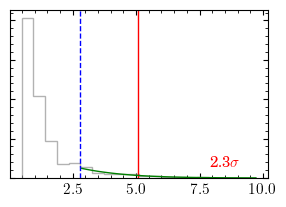

Prob of obtaining (ΔH%, nσ) = [14.   2.6] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 9.36σ, p-value: 0
Probability of target value: 0.00065\,(3.41\sigma)
Frequentist:1/1251 p=0.0007993605115907274 (3.3530161187441654)


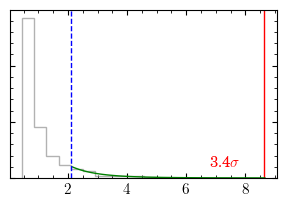

In [27]:
file_path_mc = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mcmc_random.csv'
data_type_mc = 'mc'
data_mc = load_data(file_path_mc, data_type_mc)

target_point_arr_mc = [np.array([8.7, 2.4]), np.array([14, 2.6])]
for relation, target_point in zip([r'$L_\mathrm{{X}}-T$', r'$Y_\mathrm{{SZ}}-T$'], target_point_arr_mc):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_mc, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 90
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.2g}\\,({sigma_evt:.3g}\\sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # One can get the frequency when the sigma value is low
    p_value_freq = np.sum(delta_h0_proj > target_value)/len(delta_h0_proj)
    n_sigma_freq = cf.n_sigma1d(p_value_freq)
    print(f'Frequentist:{np.sum(delta_h0_proj > target_value)}/{len(delta_h0_proj)} p={p_value_freq} ({n_sigma_freq})')

    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    cp._small_evs_(distribution=delta_h0_proj,
                   target_value=target_value,
                   x_vals=x_vals,
                   gpd_pdf=gpd_pdf,
                   threshold=threshold,
                   percentile=percentile,
                   sigma_evt=sigma_evt, color='gray')
                   
    # plt.xlabel('$x=\\Delta H_0 - \\Delta H_0 / n_\\sigma$')
    # plt.ylabel('Density')

    # plt.title(f'{relation} scattered')
    # plt.legend(fontsize=9)

    # plt.savefig(f'./to_paper/evs_mcmc_{relation[0]}_scatter_random.pdf', bbox_inches='tight')   # save the figure
    plt.show()

### With scatter

In [ ]:
import os
import pandas as pd
import numpy as np
data_dir = '/cosma8/data/do012/dc-he4/analysis'

dict = {}
for lc in range(1728):
    lc00 = f'{lc:04d}'

    filename = f'{data_dir}/lc{lc00}/h0_mcmc_scatter_random.csv'

    # check if file exists
    if os.path.exists(filename):
        df = pd.read_csv(filename)

        # save to df
        if 'delta' not in list(dict.keys()):  # dict.keys() is of type dict_keys
            for key in df.keys():           # load all data
                dict[key] = df[key]

            length = len(df[key])           # register lightcone number
            dict['Lightcone'] = np.full(length, lc)
        else:
            for key in df.keys():           # load all data
                dict[key] = np.concatenate((dict[key], df[key]))

            length = len(df[key])           # register lightcone number
            dict['Lightcone'] = np.concatenate((dict['Lightcone'], np.full(length, lc)))

    else:
        print(lc00, 'h0_mcmc_scatter_random.csv not found.')
        continue
    
data = pd.DataFrame(dict)

data

1181 h0_mcmc_scatter_random.csv not found.
1215 h0_mcmc_scatter_random.csv not found.


,scaling_relation,delta,delta_err_lower,delta_err_upper,vlon,vlon_err_lower,vlon_err_upper,vlat,vlat_err_lower,vlat_err_upper,convergence_time,Lightcone
0,LX-T,0.032777,0.022719,0.031096,-47.987415,108.691453,42.037049,11.533901,32.860735,39.169833,101.462633,0
1,YSZ-T,0.018351,0.012598,0.021273,35.971807,88.295669,82.404175,7.276810,53.336575,47.091321,104.620423,0
2,LX-T,0.018829,0.013071,0.020799,47.920840,93.957641,91.004917,-10.266501,48.936495,54.907833,86.745446,1
3,YSZ-T,0.017897,0.012463,0.019904,47.846334,74.656280,89.090568,-6.180097,48.557786,50.672796,85.614725,1
4,LX-T,0.021276,0.014463,0.022306,-0.003107,111.369450,86.940737,29.941035,55.835871,40.290967,87.353630,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3446,YSZ-T,0.019151,0.013280,0.017908,-167.970700,100.493849,115.138891,-38.741208,35.058917,58.072851,109.132971,1725
3447,LX-T,0.033123,0.019777,0.021326,167.990214,132.179925,79.467465,56.681252,33.979408,22.918148,104.610041,1726
3448,YSZ-T,0.020421,0.014218,0.022509,-119.998837,71.316067,75.173501,3.624388,48.156218,47.885974,111.081060,1726
3449,LX-T,0.031377,0.019677,0.024089,-35.960033,92.751359,60.893122,43.623370,35.717172,30.785652,82.376786,1727


In [ ]:
# Get the significance
significance = data['delta'] / data['delta_err_lower']
data['Significance'] = significance
data['DeltaH0'] = data['delta'] * 2 * 100 # to percentage

In [ ]:
data.to_csv('../data/analysis_all/h0_mc_scatter_random.csv')

### Fit and plot

Prob of obtaining (ΔH%, nσ) = [8.7 2.4] in LX-T.
Sigma deviation: 2.01σ, p-value: 0.0445
Probability of target value: 0.083\,(1.74\sigma)
Frequentist:139/1726 p=0.08053302433371959 (1.7476016794750073)


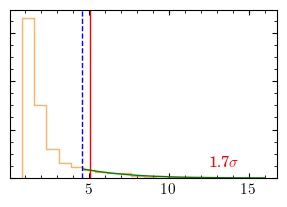

Prob of obtaining (ΔH%, nσ) = [14.   2.6] in YSZ-T.
Sigma deviation: 5.08σ, p-value: 3.82e-07
Probability of target value: 0.0094\,(2.6\sigma)
Frequentist:16/1725 p=0.00927536231884058 (2.601734519203647)


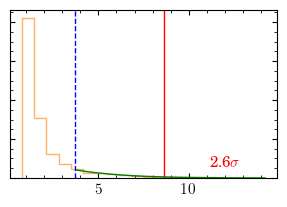

In [ ]:
file_path_mc = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mc_scatter_random.csv'
data_type_mc = 'mc'
data_mc = load_data(file_path_mc, data_type_mc)

target_point_arr_mc = [np.array([8.7, 2.4]), np.array([14, 2.6])]
for relation, target_point in zip(['LX-T', 'YSZ-T'], target_point_arr_mc):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_mc, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 90
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.2g}\\,({sigma_evt:.3g}\\sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # One can get the frequency when the sigma value is low
    p_value_freq = np.sum(delta_h0_proj > target_value)/len(delta_h0_proj)
    n_sigma_freq = cf.n_sigma1d(p_value_freq)
    print(f'Frequentist:{np.sum(delta_h0_proj > target_value)}/{len(delta_h0_proj)} p={p_value_freq} ({n_sigma_freq})')

    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    cp._small_evs_(distribution=delta_h0_proj,
                   target_value=target_value,
                   x_vals=x_vals,
                   gpd_pdf=gpd_pdf,
                   threshold=threshold,
                   percentile=percentile,
                   sigma_evt=sigma_evt, color='#ff7f00')
                   
    # plt.xlabel('$x=\\Delta H_0 - \\Delta H_0 / n_\\sigma$')
    # plt.ylabel('Density')

    # plt.title(f'{relation} scattered')
    # plt.legend(fontsize=9)

    # plt.savefig(f'./to_paper/evs_mcmc_{relation[0]}_scatter_random.pdf', bbox_inches='tight')   # save the figure
    plt.show()

## Main result (with scatter)

In [ ]:
file_path = '../data/analysis_all/h0_mc_joint_scatter_random.csv'
data = load_data(file_path, 'joint')
print(len(data))

1462


In [ ]:
# ** This plot is put in the paper **
target_point = np.array([9.0, 5.9])

print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in joint result.')
delta_h0 = data['DeltaH0'].values
significance = data['Significance'].values
delta_h0_proj = default_proj(delta_h0, significance)
target_value = default_proj(target_point[0], target_point[1])

sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")

percentile = 90
p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")

# One can get the frequency when the sigma value is low
p_value_freq = np.sum(delta_h0_proj > target_value)/len(delta_h0_proj)
n_sigma_freq = cf.n_sigma1d(p_value_freq)
print(f'Frequentist:{np.sum(delta_h0_proj > target_value)}/{len(delta_h0_proj)} p={p_value_freq} ({n_sigma_freq})')
    
threshold = np.percentile(delta_h0_proj, percentile)
exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
params = genpareto.fit(exceedances)
shape, loc, scale = params

# error bar
params_lower, params_upper = cf.bootstrap_fit(exceedances)
print('fit params:', params_lower, 'to', params_upper)

Prob of obtaining (ΔH%, nσ) = [9.  5.9] in joint result.
Sigma deviation: 2.93σ, p-value: 0.00338
Probability of target value: 0.0206, (2.31sigma)
Frequentist:30/1462 p=0.02051983584131327 (2.316704471349311)


fit params: [-2.10667039e-01  4.64140116e-05  1.87436647e+00] to [-0.05174175  0.0024454   2.39420426]


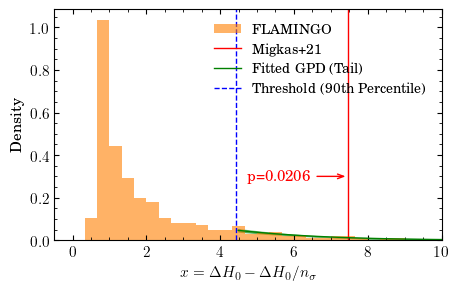

In [ ]:
# Plotting results for joint result
plt.figure(figsize=(5, 3))
x_vals = np.linspace(threshold, 10, 100)

gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100) # fitted genpareto distribution
gpd_pdf0 = genpareto.pdf(x_vals - threshold, *params_lower) * (1 - percentile / 100) # lower bound
gpd_pdf1 = genpareto.pdf(x_vals - threshold, *params_upper) * (1 - percentile / 100) # upper bound

plt.fill_between(x_vals[1:], gpd_pdf0[1:], gpd_pdf1[1:], color='g', alpha=0.5)
plt.hist(delta_h0_proj, bins=30, range=(0, 10), density=True, alpha=0.6, color='#ff7f00', label='FLAMINGO')
plt.axvline(target_value, color='red', linestyle='-', label=f'Migkas+21')
plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')
plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({percentile}th Percentile)')

# Annotate the plot
plt.annotate(f'p={p_value_evt:.3g}', 
         xy=(target_value, 0.3), xycoords='data',
         xytext=(target_value - 1, 0.3), textcoords='data',
         arrowprops=dict(arrowstyle='->,head_width=.15', color='red'),
         horizontalalignment='right', verticalalignment='center', color='red')
# # Annotate the plot
# plt.annotate(f'{sigma_evt:.3g}$\\sigma$', 
#         xy=(0.8, 0.23), xycoords='figure fraction',
#         xytext=(0.8, 0.23), textcoords='figure fraction',
#         horizontalalignment='right', verticalalignment='center', color='red')

plt.xlabel('$x=\\Delta H_0 - \\Delta H_0 / n_\\sigma$')
plt.ylabel('Density')
plt.xlim(right=10)
# plt.yscale('log')
plt.legend(fontsize=10)


# plt.savefig('./to_paper/evs_joint_scatter_random.pdf', bbox_inches='tight')
plt.show()